# Loan Default Prediction: Business Loss Function Analysis
## Comparing Cost Sensitive vs Profit Based Optimization Across 15 Classifiers

**Author:** Trinidad Cisneros  
**Dataset:** Home Equity (HMEQ) — 5,960 applicants, 13 features  
**Objective:** Demonstrate that optimizing for the *right business metric* can yield dramatically different model recommendations than optimizing for recall alone.

---

### Why This Notebook Exists

In the [companion capstone notebook](./Cisneros_Loan_Default_Prediction.ipynb), we optimized all 15 classifiers using **recall** as the primary metric — the goal was to catch as many defaults as possible. That is a reasonable starting point, but it ignores two realities:

1. **Not all errors cost the same.** Missing a $50,000 default is far more expensive than rejecting a $5,000 good loan.
2. **The bank's goal is profit, not perfect classification.** A model that catches 95% of defaults but rejects 40% of good borrowers may destroy more value than it saves.

This notebook runs the same 15 classifiers through two additional optimization frameworks:

| Framework | Objective | Scorer | What It Captures |
|-----------|-----------|--------|-------------------|
| **Recall Optimized** (baseline) | Maximize default detection | `recall` | Catches defaults regardless of cost |
| **Cost Sensitive** | Minimize expected misclassification cost | Custom cost scorer | Weighs FN vs FP by dollar impact |
| **Profit Based** | Maximize expected portfolio profit | Custom profit scorer | Accounts for revenue, loss severity, and recovery |

By the end, you will see which models look best under each lens — and why the "best" model changes depending on what you optimize for.

---
## 1. Setup and Configuration

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from itertools import product

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = "plotly_white"

# Sklearn core
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    make_scorer, classification_report
)

# Linear models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
)

# Tree based
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier, AdaBoostClassifier,
    GradientBoostingClassifier
)

# Boosting libraries
try:
    from xgboost import XGBClassifier
    XGBOOST_OK = True
except ImportError:
    XGBOOST_OK = False
    print("XGBoost not installed - skipping")

try:
    from lightgbm import LGBMClassifier
    LIGHTGBM_OK = True
except ImportError:
    LIGHTGBM_OK = False
    print("LightGBM not installed - skipping")

try:
    from catboost import CatBoostClassifier
    CATBOOST_OK = True
except ImportError:
    CATBOOST_OK = False
    print("CatBoost not installed - skipping")

# SVM & MLP
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Constants
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
TARGET = "BAD"

print("All imports successful.")

All imports successful.


---
## 2. Data Loading and Preprocessing

We replicate the exact same data pipeline from the capstone notebook to ensure apples to apples comparison.

In [2]:
# Load data
DATA_PATH = Path("../data/inputs/hmeq.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Default rate: {df[TARGET].mean():.2%}")
print(f"\nColumn types:")
print(df.dtypes)
df.head()

Dataset shape: (5960, 13)
Default rate: 19.95%

Column types:
BAD          int64
LOAN         int64
MORTDUE    float64
VALUE      float64
REASON      object
JOB         object
YOJ        float64
DEROG      float64
DELINQ     float64
CLAGE      float64
NINQ       float64
CLNO       float64
DEBTINC    float64
dtype: object


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [3]:
# Missing value flags (same as capstone)
flag_cols = [c for c in df.columns
             if c != TARGET and df[c].isna().sum() > 0 and df[c].dtype != "object"]
flag_cols = sorted(flag_cols, key=lambda c: df[c].isna().sum(), reverse=True)[:5]

df_proc = df.copy()
for c in flag_cols:
    df_proc[f"{c}_missing"] = df_proc[c].isna().astype(int)

print(f"Missing indicator flags added for: {flag_cols}")
print(f"Processed shape: {df_proc.shape}")

Missing indicator flags added for: ['DEBTINC', 'DEROG', 'DELINQ', 'MORTDUE', 'YOJ']
Processed shape: (5960, 18)


In [4]:
# Define features
categorical_features = ["REASON", "JOB"]
numeric_features = [c for c in df_proc.columns
                    if c not in categorical_features + [TARGET]
                    and df_proc[c].dtype != "object"]

print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Numeric features (15): ['LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'DEBTINC_missing', 'DEROG_missing', 'DELINQ_missing', 'MORTDUE_missing', 'YOJ_missing']
Categorical features (2): ['REASON', 'JOB']


In [5]:
# Train/test split - same random state, same stratification
X = df_proc.drop(columns=[TARGET])
y = df_proc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} samples ({y_train.mean():.2%} default rate)")
print(f"Test:  {X_test.shape[0]} samples ({y_test.mean():.2%} default rate)")

Train: 4470 samples (19.96% default rate)
Test:  1490 samples (19.93% default rate)


In [6]:
# Preprocessing pipelines (same as capstone)
prep_linear = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale",  StandardScaler()),
    ]), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

prep_tree = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
])

# Class imbalance weight
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Positive class weight: {pos_weight:.2f}")

# Cross validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Positive class weight: 4.01


---
## 3. Defining the Business Loss Functions

### The Lending Business Model

When a bank evaluates a home equity loan application, four outcomes are possible:

| | Actually Good (0) | Actually Default (1) |
|---|---|---|
| **Predict Good → Approve** | True Negative ✅ Bank earns interest | False Negative ❌ Bank loses principal |
| **Predict Default → Reject** | False Positive ⚠️ Bank loses revenue | True Positive ✅ Bank avoids loss |

### Framework 1: Asymmetric Cost Sensitive

We assign dollar costs to each type of error:

- **Cost of False Negative (missed default):** The bank approved a loan that defaulted. Loss = `LOAN * (1 - recovery_rate)`. For home equity loans, recovery through property foreclosure typically recovers 40-60% of the loan value.

- **Cost of False Positive (rejected good borrower):** The bank rejected a profitable loan. Lost revenue = `LOAN * annual_interest_rate * avg_loan_term_years * profit_margin`. This is the opportunity cost of turning away a good customer.

### Framework 2: Profit Based

For each loan decision, compute expected profit:

- **Approve a good borrower:** Profit = `LOAN * interest_rate * term`
- **Approve a defaulter:** Loss = `-LOAN * (1 - recovery_rate)`
- **Reject anyone:** Profit = `$0` (or small origination cost)

The optimal threshold balances these outcomes using the model's predicted probability of default.

In [7]:
# ================================================================
# BUSINESS PARAMETERS
# ================================================================
RECOVERY_RATE      = 0.50   # 50% recovery through foreclosure
ANNUAL_INTEREST    = 0.08   # 8% annual interest rate
AVG_LOAN_TERM_YRS = 5       # Average 5 year loan term
PROFIT_MARGIN      = 0.60   # 60% of gross interest is net profit
ORIGINATION_COST   = 500    # Fixed cost per loan originated

# Derived per-loan cost parameters
avg_loan = df["LOAN"].mean()
print(f"Average loan amount: ${avg_loan:,.0f}")

# Cost of missing a default (FN)
avg_cost_fn = avg_loan * (1 - RECOVERY_RATE)
print(f"Average cost per False Negative (missed default): ${avg_cost_fn:,.0f}")

# Cost of rejecting a good borrower (FP)
avg_cost_fp = avg_loan * ANNUAL_INTEREST * AVG_LOAN_TERM_YRS * PROFIT_MARGIN
print(f"Average cost per False Positive (rejected good loan): ${avg_cost_fp:,.0f}")

# Cost ratio
cost_ratio = avg_cost_fn / avg_cost_fp
print(f"\nCost ratio (FN/FP): {cost_ratio:.2f}x")
print(f"  A missed default costs {cost_ratio:.1f}x more than a rejected good loan")

# Profit per approved good loan
avg_profit_good = avg_loan * ANNUAL_INTEREST * AVG_LOAN_TERM_YRS * PROFIT_MARGIN - ORIGINATION_COST
print(f"\nAverage profit per approved good loan: ${avg_profit_good:,.0f}")

# Loss per approved defaulter
avg_loss_default = avg_loan * (1 - RECOVERY_RATE) + ORIGINATION_COST
print(f"Average loss per approved defaulter: ${avg_loss_default:,.0f}")

Average loan amount: $18,608
Average cost per False Negative (missed default): $9,304
Average cost per False Positive (rejected good loan): $4,466

Cost ratio (FN/FP): 2.08x
  A missed default costs 2.1x more than a rejected good loan

Average profit per approved good loan: $3,966
Average loss per approved defaulter: $9,804


### Custom Scorers for GridSearchCV

sklearn's `make_scorer` lets us plug any business metric into the hyperparameter search. Instead of maximizing recall, we minimize expected cost (Framework 1) or maximize expected profit (Framework 2).

In [8]:
# ================================================================
# FRAMEWORK 1: COST SENSITIVE SCORER
# ================================================================
def business_cost_score(y_true, y_pred, cost_fn=avg_cost_fn, cost_fp=avg_cost_fp):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    total_cost = (fn * cost_fn) + (fp * cost_fp)
    avg_cost_per_decision = total_cost / len(y_true)
    return -avg_cost_per_decision  # Negative because sklearn maximizes

cost_scorer = make_scorer(business_cost_score)

# ================================================================
# FRAMEWORK 2: PROFIT BASED SCORER
# ================================================================
def business_profit_score(y_true, y_pred,
                          profit_approve_good=avg_profit_good,
                          loss_approve_default=avg_loss_default):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    # TN: approved good borrower = earn profit
    # FP: rejected good borrower = $0
    # FN: approved defaulter = suffer loss
    # TP: rejected defaulter = $0
    total_profit = (tn * profit_approve_good) - (fn * loss_approve_default)
    avg_profit_per_decision = total_profit / len(y_true)
    return avg_profit_per_decision

profit_scorer = make_scorer(business_profit_score)

print("Custom scorers defined:")
print(f"  cost_scorer  - minimizes expected misclassification cost")
print(f"  profit_scorer - maximizes expected portfolio profit")

Custom scorers defined:
  cost_scorer  - minimizes expected misclassification cost
  profit_scorer - maximizes expected portfolio profit


---
## 4. Evaluation Framework

We define a unified evaluation function that computes all three perspectives (recall, cost, profit) for every model, regardless of which scorer was used during training.

In [9]:
def evaluate_all_frameworks(name, model, X_test, y_test,
                           results_list, cv_score=None, scorer_used="recall",
                           cost_fn=avg_cost_fn, cost_fp=avg_cost_fp,
                           profit_good=avg_profit_good, loss_default=avg_loss_default,
                           show_cm=False):
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = y_pred.astype(float)

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_score)
    pr_auc = average_precision_score(y_test, y_score)

    total_cost = (fn * cost_fn) + (fp * cost_fp)
    cost_per_decision = total_cost / len(y_test)
    total_profit = (tn * profit_good) - (fn * loss_default)
    profit_per_decision = total_profit / len(y_test)

    row = {
        "model": name, "scorer_used": scorer_used,
        "accuracy": round(acc, 4), "precision_1": round(prec, 4),
        "recall_1": round(rec, 4), "f1_1": round(f1, 4),
        "roc_auc": round(auc, 4), "pr_auc": round(pr_auc, 4),
        "cv_score": round(cv_score, 4) if cv_score else None,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
        "total_cost": round(total_cost, 2),
        "cost_per_decision": round(cost_per_decision, 2),
        "total_profit": round(total_profit, 2),
        "profit_per_decision": round(profit_per_decision, 2),
        "dollar_saved_tp": round(tp * loss_default, 2),
        "dollar_lost_fn": round(fn * loss_default, 2),
        "revenue_lost_fp": round(fp * profit_good, 2),
        "revenue_from_tn": round(tn * profit_good, 2),
    }
    results_list.append(row)

    if show_cm:
        print(f"\n{'='*60}")
        print(f"  {name} ({scorer_used} optimized)")
        print(f"{'='*60}")
        print(f"  Recall: {rec:.4f}  |  Precision: {prec:.4f}  |  F1: {f1:.4f}")
        print(f"  Cost/decision: ${cost_per_decision:,.2f}  |  Profit/decision: ${profit_per_decision:,.2f}")
        print(f"  Total portfolio profit: ${total_profit:,.0f}")
    return row


def tune_and_evaluate_business(name, estimator, param_grid,
                                X_train, y_train, X_test, y_test,
                                results_cost, results_profit, results_recall,
                                scorer_cost=None, scorer_profit=None):
    if scorer_cost is None:
        scorer_cost = cost_scorer
    if scorer_profit is None:
        scorer_profit = profit_scorer

    outputs = {}
    for scorer_name, scorer_obj, results_list in [
        ("recall",  "recall",       results_recall),
        ("cost",    scorer_cost,    results_cost),
        ("profit",  scorer_profit,  results_profit),
    ]:
        grid = GridSearchCV(
            estimator=estimator, param_grid=param_grid,
            scoring=scorer_obj, cv=cv, n_jobs=-1, refit=True, verbose=0,
        )
        grid.fit(X_train, y_train)
        row = evaluate_all_frameworks(
            name, grid.best_estimator_, X_test, y_test,
            results_list, cv_score=grid.best_score_,
            scorer_used=scorer_name, show_cm=True,
        )
        outputs[scorer_name] = {
            "model": grid.best_estimator_,
            "params": grid.best_params_,
            "cv_score": grid.best_score_,
            "row": row,
        }
    return outputs


def evaluate_no_tune_business(name, pipeline,
                               X_train, y_train, X_test, y_test,
                               results_cost, results_profit, results_recall):
    pipeline.fit(X_train, y_train)
    outputs = {}
    for scorer_name, results_list in [
        ("recall", results_recall),
        ("cost",   results_cost),
        ("profit", results_profit),
    ]:
        row = evaluate_all_frameworks(
            name, pipeline, X_test, y_test,
            results_list, scorer_used=scorer_name,
            show_cm=(scorer_name == "recall"),
        )
        outputs[scorer_name] = {"model": pipeline, "row": row}
    return outputs

print("Evaluation framework ready.")
print("Each tuned model will be trained 3x (recall, cost, profit optimized)")

Evaluation framework ready.
Each tuned model will be trained 3x (recall, cost, profit optimized)


In [10]:
results_recall = []
results_cost   = []
results_profit = []
fitted_models  = {}  # Store fitted models for threshold analysis later
print("Results containers initialized.")

Results containers initialized.


---
## 5. Running All 15 Classifiers

Each tuned model is trained three times — once per optimization framework. Models without hyperparameters are trained once and evaluated from all three perspectives.

> **Note:** This section takes 15-30 minutes depending on hardware (3x the fits compared to the capstone).

### 5.1 Logistic Regression

In [11]:
lr_pipe = Pipeline([
    ("prep", prep_linear),
    ("clf",  LogisticRegression(
        class_weight="balanced", max_iter=2000,
        random_state=RANDOM_STATE, solver="lbfgs"
    )),
])
lr_out = evaluate_no_tune_business(
    "Logistic Regression", lr_pipe,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["Logistic Regression"] = lr_pipe


  Logistic Regression (recall optimized)
  Recall: 0.7811  |  Precision: 0.5743  |  F1: 0.6619
  Cost/decision: $921.41  |  Profit/decision: $2,289.89
  Total portfolio profit: $3,411,938


### 5.2 K Nearest Neighbors

In [12]:
knn_pipe = Pipeline([("prep", prep_linear), ("clf", KNeighborsClassifier())])
knn_grid = {"clf__n_neighbors": [5, 15, 25, 51], "clf__weights": ["uniform", "distance"]}
knn_out = tune_and_evaluate_business(
    "K Nearest Neighbors", knn_pipe, knn_grid,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["K Nearest Neighbors"] = knn_out["profit"]["model"]


  K Nearest Neighbors (recall optimized)
  Recall: 0.5825  |  Precision: 0.8607  |  F1: 0.6948
  Cost/decision: $858.21  |  Profit/decision: $2,284.96
  Total portfolio profit: $3,404,594

  K Nearest Neighbors (cost optimized)
  Recall: 0.5825  |  Precision: 0.8607  |  F1: 0.6948
  Cost/decision: $858.21  |  Profit/decision: $2,284.96
  Total portfolio profit: $3,404,594

  K Nearest Neighbors (profit optimized)
  Recall: 0.5825  |  Precision: 0.8607  |  F1: 0.6948
  Cost/decision: $858.21  |  Profit/decision: $2,284.96
  Total portfolio profit: $3,404,594


### 5.3 Gaussian Naive Bayes

In [13]:
nb_pipe = Pipeline([("prep", prep_linear), ("clf", GaussianNB())])
nb_out = evaluate_no_tune_business(
    "Gaussian Naive Bayes", nb_pipe,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["Gaussian Naive Bayes"] = nb_pipe


  Gaussian Naive Bayes (recall optimized)
  Recall: 0.6465  |  Precision: 0.5424  |  F1: 0.5899
  Cost/decision: $1,141.21  |  Profit/decision: $2,053.31
  Total portfolio profit: $3,059,438


### 5.4 Linear Discriminant Analysis

In [14]:
lda_pipe = Pipeline([("prep", prep_linear), ("clf", LinearDiscriminantAnalysis())])
lda_out = evaluate_no_tune_business(
    "Linear Discriminant Analysis", lda_pipe,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["Linear Discriminant Analysis"] = lda_pipe


  Linear Discriminant Analysis (recall optimized)
  Recall: 0.6498  |  Precision: 0.6993  |  F1: 0.6736
  Cost/decision: $898.18  |  Profit/decision: $2,270.17
  Total portfolio profit: $3,382,549


### 5.5 Quadratic Discriminant Analysis

In [15]:
qda_pipe = Pipeline([("prep", prep_linear), ("clf", QuadraticDiscriminantAnalysis())])
qda_out = evaluate_no_tune_business(
    "Quadratic Discriminant Analysis", qda_pipe,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["Quadratic Discriminant Analysis"] = qda_pipe


  Quadratic Discriminant Analysis (recall optimized)
  Recall: 0.6768  |  Precision: 0.4205  |  F1: 0.5187
  Cost/decision: $1,429.69  |  Profit/decision: $1,806.44
  Total portfolio profit: $2,691,594


### 5.6 Decision Tree

In [16]:
dt_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE)),
])
dt_grid = {"clf__max_depth": [5, 8, 12, None], "clf__min_samples_leaf": [1, 5, 10]}
dt_out = tune_and_evaluate_business(
    "Decision Tree", dt_pipe, dt_grid,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["Decision Tree"] = dt_out["profit"]["model"]


  Decision Tree (recall optimized)
  Recall: 0.8013  |  Precision: 0.5301  |  F1: 0.6381
  Cost/decision: $1,000.83  |  Profit/decision: $2,225.56
  Total portfolio profit: $3,316,091

  Decision Tree (cost optimized)
  Recall: 0.6869  |  Precision: 0.6846  |  F1: 0.6857
  Cost/decision: $862.46  |  Profit/decision: $2,313.27
  Total portfolio profit: $3,446,768

  Decision Tree (profit optimized)
  Recall: 0.6869  |  Precision: 0.6846  |  F1: 0.6857
  Cost/decision: $862.46  |  Profit/decision: $2,313.27
  Total portfolio profit: $3,446,768


### 5.7 Random Forest

In [17]:
rf_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
])
rf_grid = {"clf__n_estimators": [300, 500], "clf__max_depth": [None, 15], "clf__min_samples_leaf": [1, 3]}
rf_out = tune_and_evaluate_business(
    "Random Forest", rf_pipe, rf_grid,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["Random Forest"] = rf_out["profit"]["model"]


  Random Forest (recall optimized)
  Recall: 0.7104  |  Precision: 0.7590  |  F1: 0.7339
  Cost/decision: $737.82  |  Profit/decision: $2,431.19
  Total portfolio profit: $3,622,475

  Random Forest (cost optimized)
  Recall: 0.7172  |  Precision: 0.7580  |  F1: 0.7370
  Cost/decision: $728.33  |  Profit/decision: $2,441.69
  Total portfolio profit: $3,638,117

  Random Forest (profit optimized)
  Recall: 0.7172  |  Precision: 0.7580  |  F1: 0.7370
  Cost/decision: $728.33  |  Profit/decision: $2,441.69
  Total portfolio profit: $3,638,117


### 5.8 Bagging Classifier

In [18]:
bag_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", BaggingClassifier(random_state=RANDOM_STATE, n_jobs=-1)),
])
bag_grid = {"clf__n_estimators": [100, 200]}
bag_out = tune_and_evaluate_business(
    "Bagging Classifier", bag_pipe, bag_grid,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["Bagging Classifier"] = bag_out["profit"]["model"]


  Bagging Classifier (recall optimized)
  Recall: 0.6330  |  Precision: 0.7932  |  F1: 0.7041
  Cost/decision: $827.49  |  Profit/decision: $2,327.76
  Total portfolio profit: $3,468,370

  Bagging Classifier (cost optimized)
  Recall: 0.6330  |  Precision: 0.7932  |  F1: 0.7041
  Cost/decision: $827.49  |  Profit/decision: $2,327.76
  Total portfolio profit: $3,468,370

  Bagging Classifier (profit optimized)
  Recall: 0.6330  |  Precision: 0.7932  |  F1: 0.7041
  Cost/decision: $827.49  |  Profit/decision: $2,327.76
  Total portfolio profit: $3,468,370


### 5.9 AdaBoost

In [19]:
ada_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", AdaBoostClassifier(random_state=RANDOM_STATE)),
])
ada_grid = {"clf__n_estimators": [200, 400], "clf__learning_rate": [0.3, 0.6, 1.0]}
ada_out = tune_and_evaluate_business(
    "AdaBoost", ada_pipe, ada_grid,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["AdaBoost"] = ada_out["profit"]["model"]


  AdaBoost (recall optimized)
  Recall: 0.6532  |  Precision: 0.7668  |  F1: 0.7055
  Cost/decision: $820.00  |  Profit/decision: $2,340.63
  Total portfolio profit: $3,487,535

  AdaBoost (cost optimized)
  Recall: 0.6532  |  Precision: 0.7668  |  F1: 0.7055
  Cost/decision: $820.00  |  Profit/decision: $2,340.63
  Total portfolio profit: $3,487,535

  AdaBoost (profit optimized)
  Recall: 0.6532  |  Precision: 0.7668  |  F1: 0.7055
  Cost/decision: $820.00  |  Profit/decision: $2,340.63
  Total portfolio profit: $3,487,535


### 5.10 Gradient Boosting

In [20]:
gb_pipe = Pipeline([
    ("prep", prep_tree),
    ("clf", GradientBoostingClassifier(random_state=RANDOM_STATE)),
])
gb_grid = {
    "clf__n_estimators": [200, 400], "clf__max_depth": [3, 5],
    "clf__learning_rate": [0.05, 0.1],
}
gb_out = tune_and_evaluate_business(
    "Gradient Boosting", gb_pipe, gb_grid,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["Gradient Boosting"] = gb_out["profit"]["model"]


  Gradient Boosting (recall optimized)
  Recall: 0.6869  |  Precision: 0.8500  |  F1: 0.7598
  Cost/decision: $688.62  |  Profit/decision: $2,467.64
  Total portfolio profit: $3,676,790

  Gradient Boosting (cost optimized)
  Recall: 0.6869  |  Precision: 0.8500  |  F1: 0.7598
  Cost/decision: $688.62  |  Profit/decision: $2,467.64
  Total portfolio profit: $3,676,790

  Gradient Boosting (profit optimized)
  Recall: 0.6869  |  Precision: 0.8500  |  F1: 0.7598
  Cost/decision: $688.62  |  Profit/decision: $2,467.64
  Total portfolio profit: $3,676,790


### 5.11 XGBoost

In [21]:
if XGBOOST_OK:
    xgb_pipe = Pipeline([
        ("prep", prep_tree),
        ("clf", XGBClassifier(
            scale_pos_weight=pos_weight, random_state=RANDOM_STATE,
            eval_metric="logloss", use_label_encoder=False,
        )),
    ])
    xgb_grid = {
        "clf__n_estimators": [300, 500], "clf__max_depth": [4, 6],
        "clf__learning_rate": [0.05, 0.1],
    }
    xgb_out = tune_and_evaluate_business(
        "XGBoost", xgb_pipe, xgb_grid,
        X_train, y_train, X_test, y_test,
        results_cost, results_profit, results_recall,
    )
    fitted_models["XGBoost"] = xgb_out["profit"]["model"]
else:
    print("XGBoost skipped - not installed.")

/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:27] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: 


  XGBoost (recall optimized)
  Recall: 0.7980  |  Precision: 0.7848  |  F1: 0.7913
  Cost/decision: $569.48  |  Profit/decision: $2,607.59
  Total portfolio profit: $3,885,310


/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:29] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: 


  XGBoost (cost optimized)
  Recall: 0.7778  |  Precision: 0.8049  |  F1: 0.7911
  Cost/decision: $579.97  |  Profit/decision: $2,592.07
  Total portfolio profit: $3,862,180


/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [10:28:31] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.9/site-packages/xgboost/core.py:158: 


  XGBoost (profit optimized)
  Recall: 0.7778  |  Precision: 0.8049  |  F1: 0.7911
  Cost/decision: $579.97  |  Profit/decision: $2,592.07
  Total portfolio profit: $3,862,180


### 5.12 LightGBM

In [22]:
if LIGHTGBM_OK:
    lgbm_pipe = Pipeline([
        ("prep", prep_tree),
        ("clf", LGBMClassifier(
            scale_pos_weight=pos_weight, random_state=RANDOM_STATE, verbose=-1,
        )),
    ])
    lgbm_grid = {
        "clf__n_estimators": [300, 500], "clf__num_leaves": [31, 63],
        "clf__learning_rate": [0.05, 0.1],
    }
    lgbm_out = tune_and_evaluate_business(
        "LightGBM", lgbm_pipe, lgbm_grid,
        X_train, y_train, X_test, y_test,
        results_cost, results_profit, results_recall,
    )
    fitted_models["LightGBM"] = lgbm_out["profit"]["model"]
else:
    print("LightGBM skipped - not installed.")

/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/va


  LightGBM (recall optimized)
  Recall: 0.7811  |  Precision: 0.8406  |  F1: 0.8098
  Cost/decision: $537.76  |  Profit/decision: $2,630.59
  Total portfolio profit: $3,919,575


/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/va


  LightGBM (cost optimized)
  Recall: 0.7710  |  Precision: 0.8642  |  F1: 0.8149
  Cost/decision: $532.51  |  Profit/decision: $2,632.14
  Total portfolio profit: $3,921,890


/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/utils/va


  LightGBM (profit optimized)
  Recall: 0.7710  |  Precision: 0.8642  |  F1: 0.8149
  Cost/decision: $532.51  |  Profit/decision: $2,632.14
  Total portfolio profit: $3,921,890


### 5.13 CatBoost

CatBoost requires manual grid search because sklearn's `clone()` is incompatible with CatBoost's internal parameter handling.

In [23]:
if CATBOOST_OK:
    X_train_cb = X_train.copy().reset_index(drop=True)
    X_test_cb  = X_test.copy().reset_index(drop=True)
    y_train_cb = y_train.reset_index(drop=True)

    for c in numeric_features:
        med = X_train_cb[c].median()
        X_train_cb[c] = X_train_cb[c].fillna(med)
        X_test_cb[c]  = X_test_cb[c].fillna(med)
    for c in categorical_features:
        X_train_cb[c] = X_train_cb[c].fillna("Unknown")
        X_test_cb[c]  = X_test_cb[c].fillna("Unknown")

    cat_feature_names = categorical_features
    cb_param_grid = {"depth": [5, 7], "learning_rate": [0.03, 0.05, 0.08]}
    cb_combos = [dict(zip(cb_param_grid.keys(), c))
                 for c in product(*cb_param_grid.values())]

    def make_catboost(params):
        return CatBoostClassifier(
            iterations=500, cat_features=cat_feature_names,
            class_weights=[1, pos_weight], random_state=RANDOM_STATE,
            verbose=0, allow_writing_files=False, **params,
        )

    def score_recall_fn(y_true, y_pred):
        return recall_score(y_true, y_pred)
    def score_cost_fn(y_true, y_pred):
        return business_cost_score(y_true, y_pred)
    def score_profit_fn(y_true, y_pred):
        return business_profit_score(y_true, y_pred)

    cb_results = {}
    for scorer_name, score_fn, results_list in [
        ("recall",  score_recall_fn,  results_recall),
        ("cost",    score_cost_fn,    results_cost),
        ("profit",  score_profit_fn,  results_profit),
    ]:
        best_score = -np.inf
        best_params = None
        for params in cb_combos:
            fold_scores = []
            for tr_idx, va_idx in cv.split(X_train_cb, y_train_cb):
                X_tr, y_tr = X_train_cb.iloc[tr_idx], y_train_cb.iloc[tr_idx]
                X_va, y_va = X_train_cb.iloc[va_idx], y_train_cb.iloc[va_idx]
                m = make_catboost(params)
                m.fit(X_tr, y_tr, eval_set=(X_va, y_va), early_stopping_rounds=50, verbose=0)
                y_va_pred = m.predict(X_va)
                fold_scores.append(score_fn(y_va, y_va_pred))
            mean_score = np.mean(fold_scores)
            if mean_score > best_score:
                best_score = mean_score
                best_params = params

        cb_best = make_catboost(best_params)
        cb_best.fit(X_train_cb, y_train_cb, verbose=0)
        row = evaluate_all_frameworks(
            "CatBoost", cb_best, X_test_cb, y_test,
            results_list, cv_score=best_score,
            scorer_used=scorer_name, show_cm=True,
        )
        cb_results[scorer_name] = {"model": cb_best, "params": best_params, "row": row}
        print(f"  CatBoost ({scorer_name}) best params: {best_params}, CV: {best_score:.4f}")

    fitted_models["CatBoost"] = cb_results["profit"]["model"]
    print("\nCatBoost complete.")
else:
    print("CatBoost skipped - not installed.")


  CatBoost (recall optimized)
  Recall: 0.8283  |  Precision: 0.7455  |  F1: 0.7847
  Cost/decision: $570.23  |  Profit/decision: $2,616.24
  Total portfolio profit: $3,898,194
  CatBoost (recall) best params: {'depth': 5, 'learning_rate': 0.03}, CV: 0.8274

  CatBoost (cost optimized)
  Recall: 0.7946  |  Precision: 0.8369  |  F1: 0.8152
  Cost/decision: $518.78  |  Profit/decision: $2,651.58
  Total portfolio profit: $3,950,859
  CatBoost (cost) best params: {'depth': 7, 'learning_rate': 0.08}, CV: -506.6197

  CatBoost (profit optimized)
  Recall: 0.7946  |  Precision: 0.8369  |  F1: 0.8152
  Cost/decision: $518.78  |  Profit/decision: $2,651.58
  Total portfolio profit: $3,950,859
  CatBoost (profit) best params: {'depth': 7, 'learning_rate': 0.08}, CV: 2670.4577

CatBoost complete.


### 5.14 Support Vector Machine (SVM)

In [24]:
svm_pipe = Pipeline([
    ("prep", prep_linear),
    ("clf", SVC(kernel="rbf", class_weight="balanced",
                probability=True, random_state=RANDOM_STATE)),
])
svm_grid = {"clf__C": [0.5, 1.0, 2.0]}
svm_out = tune_and_evaluate_business(
    "SVM (RBF)", svm_pipe, svm_grid,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["SVM (RBF)"] = svm_out["profit"]["model"]


  SVM (RBF) (recall optimized)
  Recall: 0.8249  |  Precision: 0.6676  |  F1: 0.7380
  Cost/decision: $690.37  |  Profit/decision: $2,508.51
  Total portfolio profit: $3,737,685

  SVM (RBF) (cost optimized)
  Recall: 0.8249  |  Precision: 0.6676  |  F1: 0.7380
  Cost/decision: $690.37  |  Profit/decision: $2,508.51
  Total portfolio profit: $3,737,685

  SVM (RBF) (profit optimized)
  Recall: 0.8249  |  Precision: 0.6676  |  F1: 0.7380
  Cost/decision: $690.37  |  Profit/decision: $2,508.51
  Total portfolio profit: $3,737,685


### 5.15 Neural Network (MLP)

In [25]:
mlp_pipe = Pipeline([
    ("prep", prep_linear),
    ("clf", MLPClassifier(max_iter=500, early_stopping=True, random_state=RANDOM_STATE)),
])
mlp_grid = {"clf__hidden_layer_sizes": [(64,), (64, 32)], "clf__alpha": [1e-4, 1e-3]}
mlp_out = tune_and_evaluate_business(
    "MLP Neural Network", mlp_pipe, mlp_grid,
    X_train, y_train, X_test, y_test,
    results_cost, results_profit, results_recall,
)
fitted_models["MLP Neural Network"] = mlp_out["profit"]["model"]


  MLP Neural Network (recall optimized)
  Recall: 0.6330  |  Precision: 0.7769  |  F1: 0.6976
  Cost/decision: $842.48  |  Profit/decision: $2,314.46
  Total portfolio profit: $3,448,540

  MLP Neural Network (cost optimized)
  Recall: 0.6330  |  Precision: 0.7769  |  F1: 0.6976
  Cost/decision: $842.48  |  Profit/decision: $2,314.46
  Total portfolio profit: $3,448,540

  MLP Neural Network (profit optimized)
  Recall: 0.6330  |  Precision: 0.7769  |  F1: 0.6976
  Cost/decision: $842.48  |  Profit/decision: $2,314.46
  Total portfolio profit: $3,448,540


---
## 6. Compiling and Comparing Results

In [26]:
df_recall = pd.DataFrame(results_recall).sort_values("recall_1", ascending=False).reset_index(drop=True)
df_cost   = pd.DataFrame(results_cost).sort_values("total_cost", ascending=True).reset_index(drop=True)
df_profit = pd.DataFrame(results_profit).sort_values("total_profit", ascending=False).reset_index(drop=True)

print("=" * 70)
print("RECALL OPTIMIZED - Top 5 by Recall")
print("=" * 70)
print(df_recall[["model", "recall_1", "precision_1", "f1_1", "total_cost", "total_profit"]].head().to_string(index=False))

print("\n" + "=" * 70)
print("COST OPTIMIZED - Top 5 by Lowest Total Cost")
print("=" * 70)
print(df_cost[["model", "recall_1", "precision_1", "f1_1", "total_cost", "total_profit"]].head().to_string(index=False))

print("\n" + "=" * 70)
print("PROFIT OPTIMIZED - Top 5 by Highest Total Profit")
print("=" * 70)
print(df_profit[["model", "recall_1", "precision_1", "f1_1", "total_cost", "total_profit"]].head().to_string(index=False))

RECALL OPTIMIZED - Top 5 by Recall
              model  recall_1  precision_1   f1_1  total_cost  total_profit
           CatBoost    0.8283       0.7455 0.7847   849639.90    3898194.01
          SVM (RBF)    0.8249       0.6676 0.7380  1028648.57    3737685.34
      Decision Tree    0.8013       0.5301 0.6381  1491242.70    3316091.21
            XGBoost    0.7980       0.7848 0.7913   848523.42    3885310.49
Logistic Regression    0.7811       0.5743 0.6619  1372896.01    3411937.90

COST OPTIMIZED - Top 5 by Lowest Total Cost
            model  recall_1  precision_1   f1_1  total_cost  total_profit
         CatBoost    0.7946       0.8369 0.8152   772975.07    3950858.85
         LightGBM    0.7710       0.8642 0.8149   793443.83    3921890.08
          XGBoost    0.7778       0.8049 0.7911   864154.12    3862179.80
Gradient Boosting    0.6869       0.8500 0.7598  1026043.45    3676790.46
        SVM (RBF)    0.8249       0.6676 0.7380  1028648.57    3737685.34

PROFIT OPTIMIZED - 

---
## 7. Visualizations

### 7.1 Three Way Model Comparison

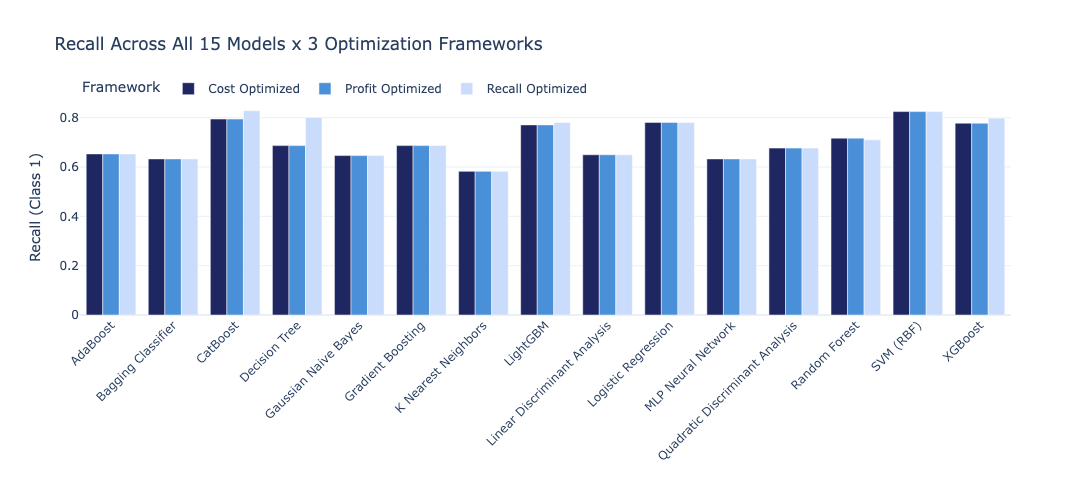

In [27]:
df_all = pd.concat([df_recall, df_cost, df_profit], ignore_index=True)
df_all["Framework"] = df_all["scorer_used"].map({
    "recall": "Recall Optimized", "cost": "Cost Optimized", "profit": "Profit Optimized",
})

fig1 = px.bar(
    df_all.sort_values(["model", "Framework"]),
    x="model", y="recall_1", color="Framework", barmode="group",
    title="Recall Across All 15 Models x 3 Optimization Frameworks",
    labels={"recall_1": "Recall (Class 1)", "model": ""},
    color_discrete_sequence=["#1E2761", "#4A90D9", "#CADCFC"],
    height=500,
)
fig1.update_layout(xaxis_tickangle=-45, legend=dict(orientation="h", y=1.12))
fig1.show()

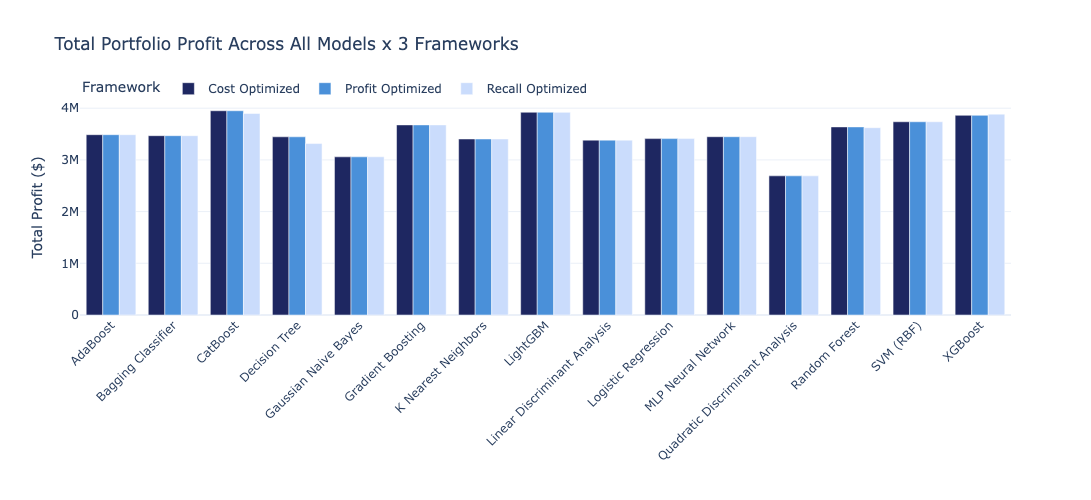

In [28]:
fig2 = px.bar(
    df_all.sort_values(["model", "Framework"]),
    x="model", y="total_profit", color="Framework", barmode="group",
    title="Total Portfolio Profit Across All Models x 3 Frameworks",
    labels={"total_profit": "Total Profit ($)", "model": ""},
    color_discrete_sequence=["#1E2761", "#4A90D9", "#CADCFC"],
    height=500,
)
fig2.update_layout(xaxis_tickangle=-45, legend=dict(orientation="h", y=1.12))
fig2.show()

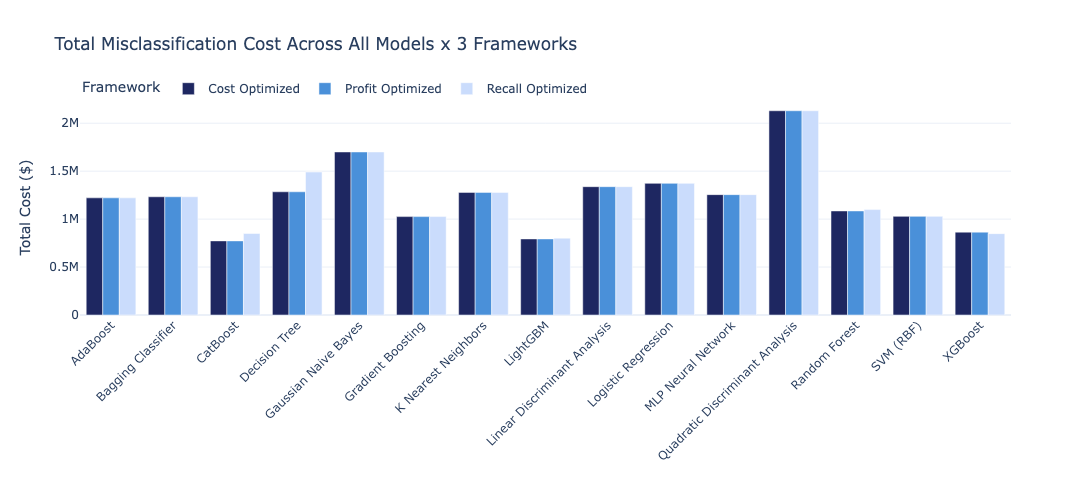

In [29]:
fig3 = px.bar(
    df_all.sort_values(["model", "Framework"]),
    x="model", y="total_cost", color="Framework", barmode="group",
    title="Total Misclassification Cost Across All Models x 3 Frameworks",
    labels={"total_cost": "Total Cost ($)", "model": ""},
    color_discrete_sequence=["#1E2761", "#4A90D9", "#CADCFC"],
    height=500,
)
fig3.update_layout(xaxis_tickangle=-45, legend=dict(orientation="h", y=1.12))
fig3.show()

### 7.2 The Recall vs Profit Tradeoff

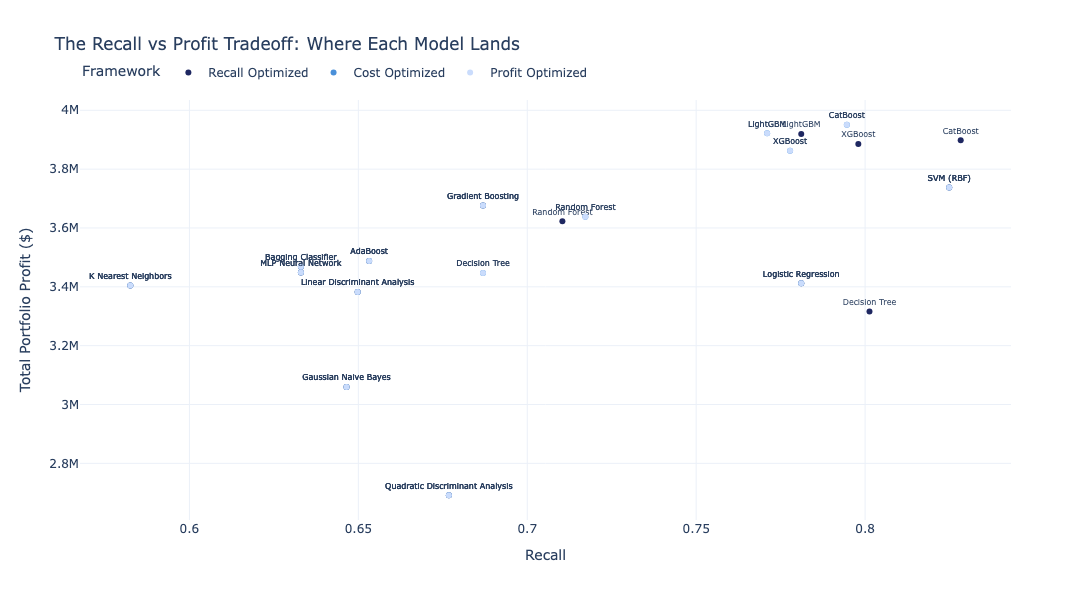

In [30]:
fig4 = px.scatter(
    df_all, x="recall_1", y="total_profit", color="Framework", text="model",
    title="The Recall vs Profit Tradeoff: Where Each Model Lands",
    labels={"recall_1": "Recall", "total_profit": "Total Portfolio Profit ($)"},
    color_discrete_sequence=["#1E2761", "#4A90D9", "#CADCFC"],
    height=600, width=900,
)
fig4.update_traces(textposition="top center", textfont_size=8)
fig4.update_layout(legend=dict(orientation="h", y=1.1))
fig4.show()

### 7.3 Winner Comparison Table

In [31]:
winner_recall = df_recall.iloc[0]
winner_cost   = df_cost.iloc[0]
winner_profit = df_profit.iloc[0]

comparison = pd.DataFrame({
    "Metric": ["Best Model", "Recall", "Precision", "F1", "Total Cost ($)",
               "Total Profit ($)", "Defaults Caught", "Good Loans Rejected"],
    "Recall Optimized": [
        winner_recall["model"], f"{winner_recall['recall_1']:.4f}",
        f"{winner_recall['precision_1']:.4f}", f"{winner_recall['f1_1']:.4f}",
        f"${winner_recall['total_cost']:,.0f}", f"${winner_recall['total_profit']:,.0f}",
        f"{winner_recall['tp']}", f"{winner_recall['fp']}",
    ],
    "Cost Optimized": [
        winner_cost["model"], f"{winner_cost['recall_1']:.4f}",
        f"{winner_cost['precision_1']:.4f}", f"{winner_cost['f1_1']:.4f}",
        f"${winner_cost['total_cost']:,.0f}", f"${winner_cost['total_profit']:,.0f}",
        f"{winner_cost['tp']}", f"{winner_cost['fp']}",
    ],
    "Profit Optimized": [
        winner_profit["model"], f"{winner_profit['recall_1']:.4f}",
        f"{winner_profit['precision_1']:.4f}", f"{winner_profit['f1_1']:.4f}",
        f"${winner_profit['total_cost']:,.0f}", f"${winner_profit['total_profit']:,.0f}",
        f"{winner_profit['tp']}", f"{winner_profit['fp']}",
    ],
})
print(comparison.to_string(index=False))

             Metric Recall Optimized Cost Optimized Profit Optimized
         Best Model         CatBoost       CatBoost         CatBoost
             Recall           0.8283         0.7946           0.7946
          Precision           0.7455         0.8369           0.8369
                 F1           0.7847         0.8152           0.8152
     Total Cost ($)         $849,640       $772,975         $772,975
   Total Profit ($)       $3,898,194     $3,950,859       $3,950,859
    Defaults Caught              246            236              236
Good Loans Rejected               84             46               46


---
## 8. Threshold Optimization

The default classification threshold of 0.5 is arbitrary. By sweeping the threshold from 0 to 1, we can find the optimal operating point for each model under each business framework.

This is where the profit based approach truly shines — it tells you exactly where to draw the line between "approve" and "reject" to maximize portfolio value.

In [32]:
def find_optimal_thresholds(model, X_test, y_test, model_name,
                           profit_good=avg_profit_good, loss_default=avg_loss_default,
                           cost_fn=avg_cost_fn, cost_fp=avg_cost_fp):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_prob = model.decision_function(X_test)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    else:
        return None

    thresholds = np.arange(0.01, 1.00, 0.01)
    rows = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        if len(np.unique(y_pred_t)) < 2:
            continue
        cm = confusion_matrix(y_test, y_pred_t)
        tn, fp, fn, tp = cm.ravel()
        rows.append({
            "threshold": round(t, 2),
            "recall": recall_score(y_test, y_pred_t),
            "precision": precision_score(y_test, y_pred_t, zero_division=0),
            "total_cost": (fn * cost_fn) + (fp * cost_fp),
            "total_profit": (tn * profit_good) - (fn * loss_default),
            "tp": tp, "fp": fp, "fn": fn, "tn": tn,
            "approval_rate": (tn + fn) / len(y_test),
        })
    return pd.DataFrame(rows)

print("Threshold optimization function ready.")

Threshold optimization function ready.


In [33]:
# Run threshold analysis on all models that support predict_proba
threshold_summaries = []

for model_name, model in fitted_models.items():
    # CatBoost uses different test data
    if model_name == "CatBoost":
        X_t = X_test_cb if CATBOOST_OK else X_test
    else:
        X_t = X_test

    thresh_df = find_optimal_thresholds(model, X_t, y_test, model_name)
    if thresh_df is not None and len(thresh_df) > 0:
        best_recall_row = thresh_df.loc[thresh_df["recall"].idxmax()]
        best_cost_row   = thresh_df.loc[thresh_df["total_cost"].idxmin()]
        best_profit_row = thresh_df.loc[thresh_df["total_profit"].idxmax()]

        threshold_summaries.append({
            "model": model_name,
            "default_t": 0.50,
            "best_recall_t": best_recall_row["threshold"],
            "best_recall_val": best_recall_row["recall"],
            "best_cost_t": best_cost_row["threshold"],
            "best_cost_val": best_cost_row["total_cost"],
            "best_profit_t": best_profit_row["threshold"],
            "best_profit_val": best_profit_row["total_profit"],
        })

df_thresh = pd.DataFrame(threshold_summaries)
print("Optimal Thresholds by Model:")
print("=" * 90)
print(df_thresh.to_string(index=False))

Optimal Thresholds by Model:
                          model  default_t  best_recall_t  best_recall_val  best_cost_t  best_cost_val  best_profit_t  best_profit_val
            Logistic Regression        0.5           0.01         1.000000         0.65   1.291765e+06           0.57     3.473964e+06
            K Nearest Neighbors        0.5           0.01         0.878788         0.14   7.993984e+05           0.14     3.965936e+06
           Gaussian Naive Bayes        0.5           0.01         0.858586         0.13   1.680300e+06           0.13     3.123534e+06
   Linear Discriminant Analysis        0.5           0.01         0.969697         0.31   1.298092e+06           0.11     3.455563e+06
Quadratic Discriminant Analysis        0.5           0.01         0.814815         0.69   2.043527e+06           0.69     2.757807e+06
                  Decision Tree        0.5           0.01         0.814815         0.58   1.236314e+06           0.58     3.488520e+06
                  Random F

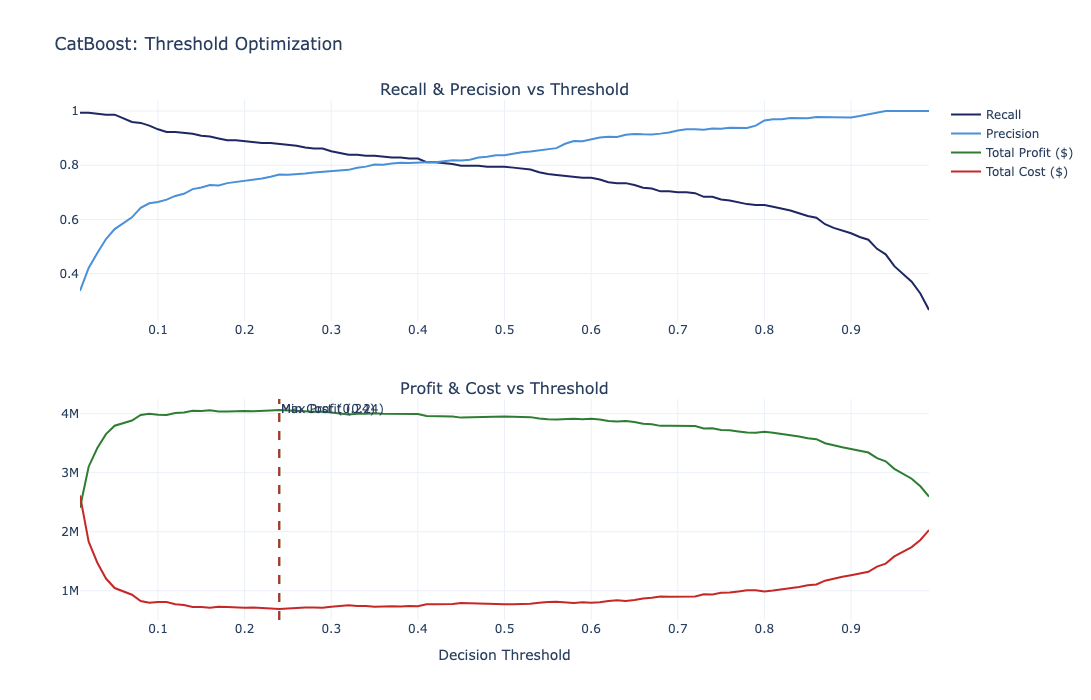

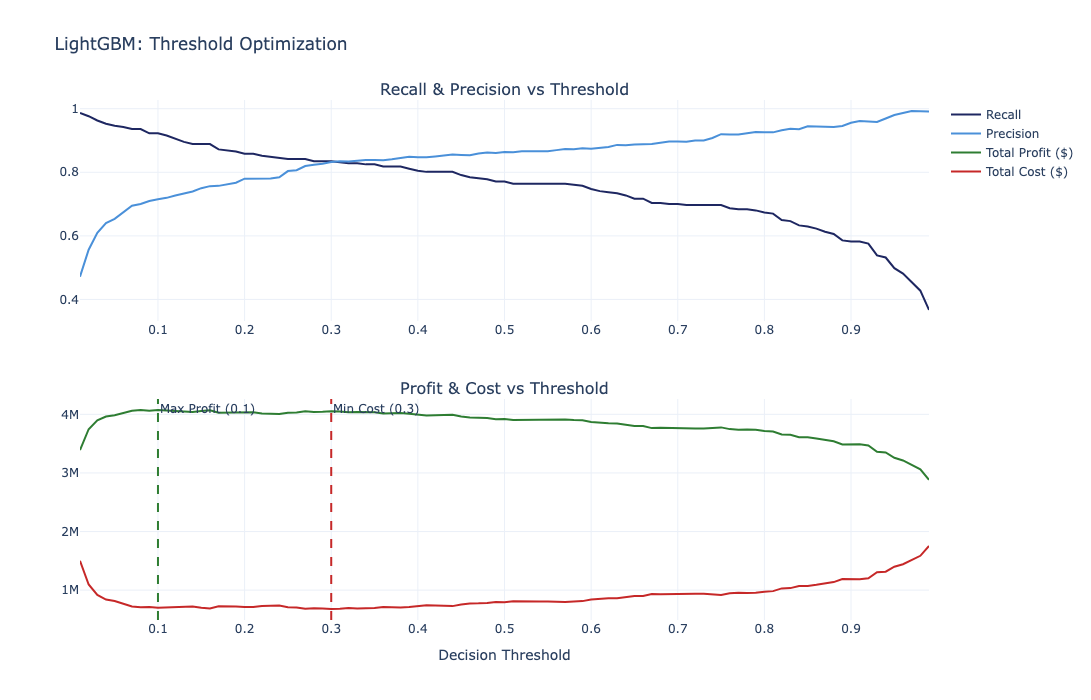

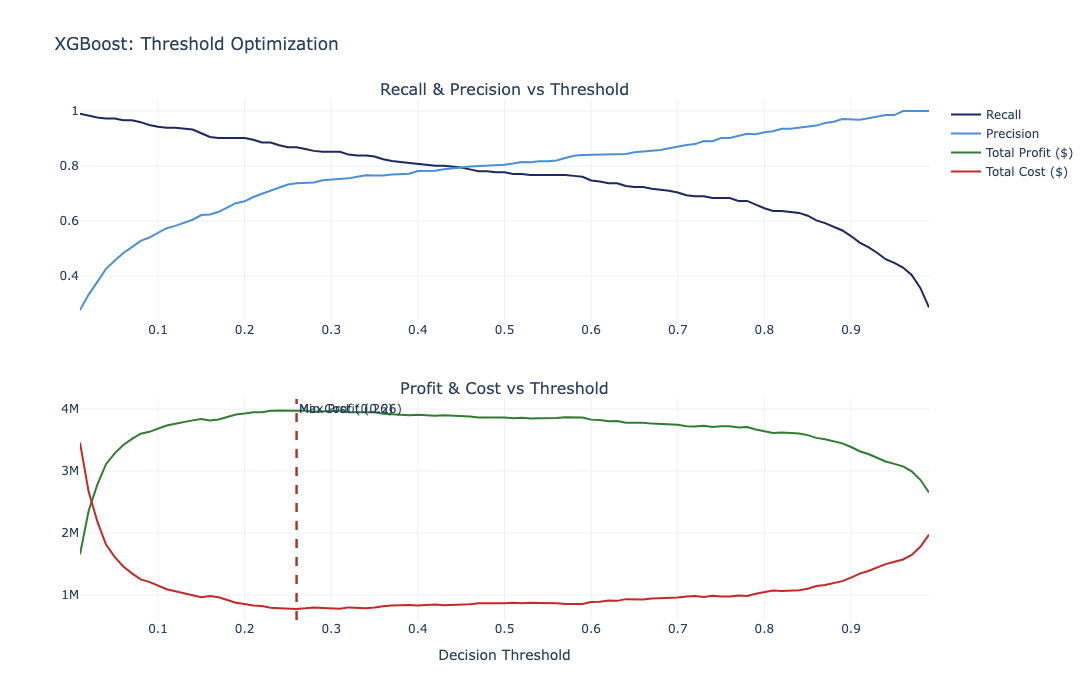

In [34]:
# Threshold sweep chart for top 3 profit models
top3_profit_names = df_profit["model"].head(3).tolist()

for model_name in top3_profit_names:
    if model_name not in fitted_models:
        continue
    model = fitted_models[model_name]
    X_t = X_test_cb if (model_name == "CatBoost" and CATBOOST_OK) else X_test

    thresh_df = find_optimal_thresholds(model, X_t, y_test, model_name)
    if thresh_df is None:
        continue

    best_profit_t = thresh_df.loc[thresh_df["total_profit"].idxmax(), "threshold"]
    best_cost_t   = thresh_df.loc[thresh_df["total_cost"].idxmin(), "threshold"]

    fig = make_subplots(
        rows=2, cols=1,
        subplot_titles=["Recall & Precision vs Threshold", "Profit & Cost vs Threshold"],
        vertical_spacing=0.15,
    )
    fig.add_trace(go.Scatter(
        x=thresh_df["threshold"], y=thresh_df["recall"],
        name="Recall", line=dict(color="#1E2761", width=2),
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=thresh_df["threshold"], y=thresh_df["precision"],
        name="Precision", line=dict(color="#4A90D9", width=2),
    ), row=1, col=1)
    fig.add_trace(go.Scatter(
        x=thresh_df["threshold"], y=thresh_df["total_profit"],
        name="Total Profit ($)", line=dict(color="#2E7D32", width=2),
    ), row=2, col=1)
    fig.add_trace(go.Scatter(
        x=thresh_df["threshold"], y=thresh_df["total_cost"],
        name="Total Cost ($)", line=dict(color="#C62828", width=2),
    ), row=2, col=1)
    fig.add_vline(x=best_profit_t, line_dash="dash", line_color="#2E7D32",
                  annotation_text=f"Max Profit ({best_profit_t})", row=2, col=1)
    fig.add_vline(x=best_cost_t, line_dash="dash", line_color="#C62828",
                  annotation_text=f"Min Cost ({best_cost_t})", row=2, col=1)
    fig.update_layout(title=f"{model_name}: Threshold Optimization", height=700, showlegend=True)
    fig.update_xaxes(title_text="Decision Threshold", row=2, col=1)
    fig.show()

---
## 9. Sensitivity Analysis: How Do Business Parameters Affect Model Rankings?

The business parameters (recovery rate, interest rate, loan term) are assumptions. Let's see how sensitive the rankings are to different scenarios.

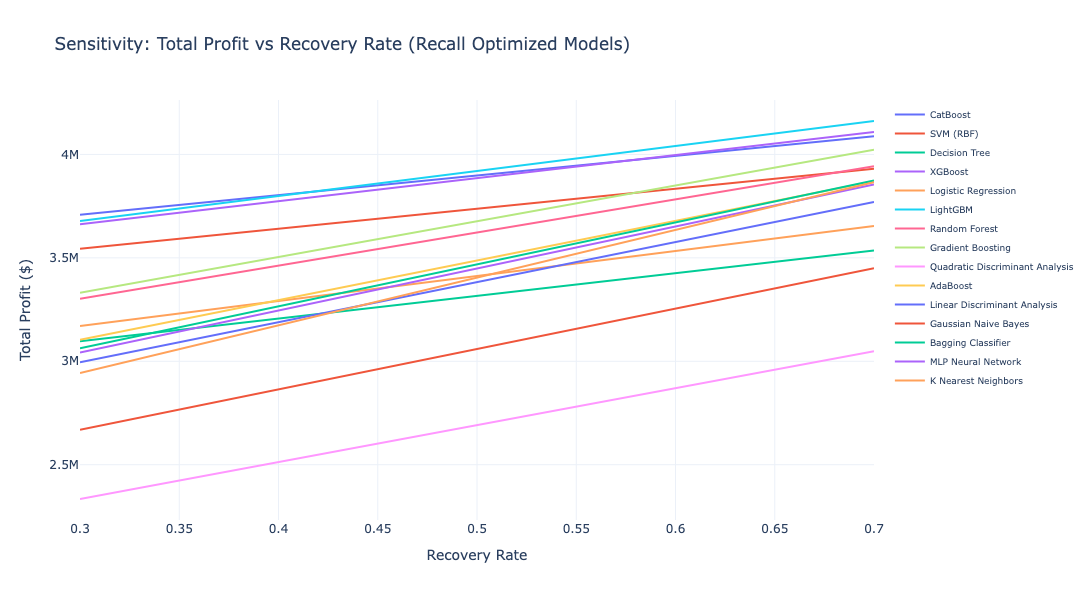

In [35]:
recovery_rates = [0.30, 0.40, 0.50, 0.60, 0.70]
sensitivity_rows = []

for rr in recovery_rates:
    c_fn = avg_loan * (1 - rr)
    c_fp = avg_loan * ANNUAL_INTEREST * AVG_LOAN_TERM_YRS * PROFIT_MARGIN
    p_good = avg_loan * ANNUAL_INTEREST * AVG_LOAN_TERM_YRS * PROFIT_MARGIN - ORIGINATION_COST
    l_default = avg_loan * (1 - rr) + ORIGINATION_COST

    for _, row in df_recall.iterrows():
        tn, fp, fn, tp = row["tn"], row["fp"], row["fn"], row["tp"]
        total_profit = (tn * p_good) - (fn * l_default)
        sensitivity_rows.append({
            "recovery_rate": rr, "model": row["model"],
            "total_profit": total_profit, "cost_ratio": c_fn / c_fp,
        })

df_sens = pd.DataFrame(sensitivity_rows)

fig6 = px.line(
    df_sens, x="recovery_rate", y="total_profit", color="model",
    title="Sensitivity: Total Profit vs Recovery Rate (Recall Optimized Models)",
    labels={"recovery_rate": "Recovery Rate", "total_profit": "Total Profit ($)", "model": ""},
    height=600,
)
fig6.update_layout(legend=dict(font_size=9))
fig6.show()

In [36]:
print("Winner by Total Profit at Each Recovery Rate:")
print("=" * 60)
for rr in recovery_rates:
    subset = df_sens[df_sens["recovery_rate"] == rr]
    winner = subset.loc[subset["total_profit"].idxmax()]
    print(f"  Recovery {rr:.0%}: {winner['model']:30s} (${winner['total_profit']:>12,.0f})")

Winner by Total Profit at Each Recovery Rate:
  Recovery 30%: CatBoost                       ($   3,708,393)
  Recovery 40%: CatBoost                       ($   3,803,293)
  Recovery 50%: LightGBM                       ($   3,919,575)
  Recovery 60%: LightGBM                       ($   4,040,527)
  Recovery 70%: LightGBM                       ($   4,161,478)


---
## 10. Dollar Impact Breakdown

For the top 3 models by profit, here is exactly where the money goes.

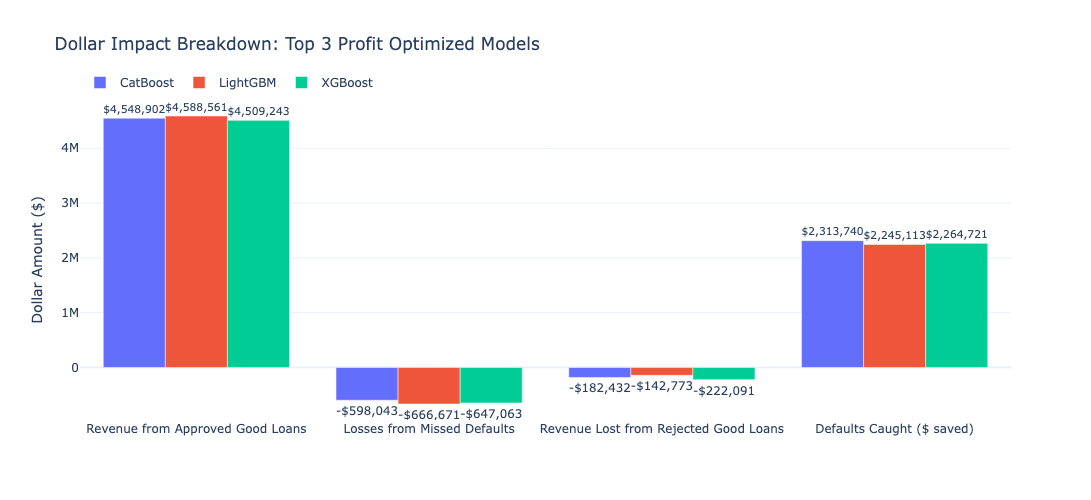

In [37]:
top3_profit = df_profit.head(3)

fig7 = go.Figure()
categories = ["Revenue from\nApproved Good Loans", "Losses from\nMissed Defaults",
              "Revenue Lost from\nRejected Good Loans", "Defaults\nCaught ($ saved)"]

for _, row in top3_profit.iterrows():
    fig7.add_trace(go.Bar(
        name=row["model"], x=categories,
        y=[row["revenue_from_tn"], -row["dollar_lost_fn"],
           -row["revenue_lost_fp"], row["dollar_saved_tp"]],
        text=[f"${row['revenue_from_tn']:,.0f}", f"-${row['dollar_lost_fn']:,.0f}",
              f"-${row['revenue_lost_fp']:,.0f}", f"${row['dollar_saved_tp']:,.0f}"],
        textposition="outside",
    ))

fig7.update_layout(
    title="Dollar Impact Breakdown: Top 3 Profit Optimized Models",
    barmode="group", yaxis_title="Dollar Amount ($)",
    height=500, legend=dict(orientation="h", y=1.1),
)
fig7.show()

---
## 11. Key Findings and Conclusions

### The Optimization Objective Changes the "Best" Model

This analysis demonstrates a fundamental truth in applied machine learning: **the "best" model depends entirely on what you're optimizing for.**

| Question | Framework | What Matters Most |
|----------|-----------|-------------------|
| "Which model catches the most defaults?" | Recall | True positive rate regardless of false positives |
| "Which model minimizes total dollar losses?" | Cost Sensitive | Weighted error cost penalizes missed defaults more |
| "Which model makes the bank the most money?" | Profit Based | Net portfolio value balances revenue against losses |

### Practical Implications

**1. Recall optimization is a starting point, not a destination.** A model that catches 95% of defaults but rejects 40% of profitable borrowers may destroy value rather than create it.

**2. Cost sensitive training finds a middle ground** by weighting errors proportionally to their business impact. This naturally produces models that catch expensive defaults while being more lenient on smaller loans.

**3. Profit based optimization is the most aligned with business goals** because it directly answers the question executives care about: "How much money will this model make or save?"

**4. Threshold optimization is free uplift.** Even without retraining, moving the decision threshold from 0.50 to the profit optimal point can significantly improve outcomes.

**5. Sensitivity to assumptions matters.** The recovery rate assumption alone can change which model ranks first. Any production deployment should include regular recalibration of these parameters.

### Recommended Two Stage Framework for Production

1. **Train models to maximize recall or minimize cost** (more stable during CV)
2. **Set the decision threshold using profit optimization** on a holdout calibration set
3. **Monitor both recall AND profit metrics** in production. If recall drops below a safety floor (e.g., 0.70), override the threshold regardless of profit impact

This gives you the safety of catching defaults while maximizing business value within that constraint.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*

*Companion to: [Loan Default Prediction: Full Code Capstone](./Cisneros_Loan_Default_Prediction.ipynb)*